Bibliotecas

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

Puxando o excel de negociações

In [32]:
df = pd.read_excel(r'C:\Users\Orçamento\OneDrive - GRUPO RETEC\02. Engenharia\Dep. Orçamentos\POWERBI\AUTOMACAO RD\data\negociacoes_2025.xlsx')

Colunas que queremos visualizar

In [33]:
df.columns

Index(['_id', 'id', 'name', 'amount_montly', 'amount_unique', 'amount_total',
       'prediction_date', 'markup', 'last_activity_at', 'interactions',
       'markup_last_activities', 'created_at', 'updated_at', 'rating',
       'markup_created', 'last_activity_content', 'user_changed', 'hold',
       'win', 'closed_at', 'contacts', 'deal_custom_fields', 'deal_products',
       'stop_time_limit.expiration_date_time', 'stop_time_limit.expired',
       'stop_time_limit.expired_days', 'organization._id', 'organization.id',
       'organization.name', 'organization.address',
       'organization.address_latitude', 'organization.address_longitude',
       'organization.user._id', 'organization.user.id',
       'organization.user.name', 'organization.user.email',
       'organization.organization_segments', 'user._id', 'user.id',
       'user.name', 'user.nickname', 'user.email', 'deal_stage._id',
       'deal_stage.id', 'deal_stage.name', 'deal_stage.nickname',
       'deal_stage.created_at'

In [34]:
colunas = [
    "id", "name",'Proposta Nº','organization.name','Nome da Obra','Unidade de Negócio','Fator','Local da Obra (Estado)',
    'Local da Obra (Cidade)','Produtos (Representação)',
    'Fábrica (Representação)','Orçamentista', "amount_total", "amount_unique", "markup",
    "created_at", "closed_at", "last_activity_at",
    "interactions", "win", "deal_stage.name", "user.id", "user.name",
    "deal_lost_reason.name",    
]

In [35]:
df_rep = df[df['user.name'].isin(['Bruno Crispim', 'Gabriel  Bento'])]
df_rep = df_rep[colunas].copy()
df_rep.loc[:, "Fator"] = (
    df_rep["Fator"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float, errors="ignore")
)

In [36]:
df_rep

,id,name,Proposta Nº,organization.name,Nome da Obra,Unidade de Negócio,Fator,Local da Obra (Estado),Local da Obra (Cidade),Produtos (Representação),...,markup,created_at,closed_at,last_activity_at,interactions,win,deal_stage.name,user.id,user.name,deal_lost_reason.name
272,681cb3ab978e2f00275fb27d,NCT 13989-25 - TECNA CONSTRUTORA - RESIDENCIAL...,NCT 13989-25,TECNA CONSTRUTORA LTDA,RESIDENCIAL RL,Representação,0.85,Distrito Federal (DF),Brasília,['DIFUSÃO'],...,future,2025-05-08T10:37:47.556-03:00,NaN,NaN,0,NaN,Consulta Enviada,6557ecc0295062000f0ac40a,Bruno Crispim,NaN
273,681cae7e320c23001baa3e1d,NCD 25050234-25 - FOX ENGENHARIA - BRB - 06.05...,NCD 25050234-25,FOX ENGENHARIA E CONSULTORIA LTDA,BRB,Representação,0.62,Tocantins (TO),Araguaína,['VRF'],...,future,2025-05-08T10:15:42.148-03:00,NaN,NaN,0,NaN,Consulta Enviada,6557ecc0295062000f0ac40a,Bruno Crispim,NaN
274,681cad029c91db001413c94a,NCS 234974-25 - FOX ENGENHARIA - BRB - 06.05.2...,NCS 234974-25,FOX ENGENHARIA E CONSULTORIA LTDA,BRB - ARAGUAÍNA,Representação,1.0,Tocantins (TO),ARAGUAÍNA,['MINI SPLIT'],...,future,2025-05-08T10:09:22.366-03:00,NaN,NaN,0,NaN,Consulta Enviada,6557ecc0295062000f0ac40a,Bruno Crispim,NaN
312,6818bf0a03c9f10014ecc56b,NOP 109282-25 - UNIAO QUIMICA - VIRICAS I - 22...,NOP 109282-25,UNIAO QUIMICA FARMACEUTICA NACIONAL S/A,VÍRICAS I,Representação,1.0,Distrito Federal (DF),Brasília,['VENTILAÇÃO/EXAUSTÃO'],...,future,2025-05-05T10:37:14.945-03:00,NaN,NaN,0,NaN,Consulta Enviada,6557ecc0295062000f0ac40a,Bruno Crispim,NaN
313,6818bea73d2c6e0027bdcc88,NCT-X 13965-25 - UNIAO QUIMICA - VIRICAS I - 2...,NCT-X 13965-25,UNIAO QUIMICA FARMACEUTICA NACIONAL S/A,VÍRICAS I,Representação,1.0,Distrito Federal (DF),Brasília,['OUTROS EQUIPAMENTOS'],...,future,2025-05-05T10:35:35.514-03:00,NaN,NaN,0,NaN,Consulta Enviada,6557ecc0295062000f0ac40a,Bruno Crispim,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3021,677c3b699321820027e7d48c,NCI 3369-24 - CONNECTOR - MULTI CONSTRUTORA - ...,NCI 3369-24,CONNECTOR ENGENHARIA LTDA,MULTI BRASIL,Representação,0.65,Distrito Federal (DF),BRASÍLIA,['TANQUES'],...,future,2025-01-06T17:22:01.459-03:00,2025-01-30T11:45:59.249-03:00,NaN,4,0.0,Venda Perdida,6557ecc0295062000f0ac40a,Bruno Crispim,Preço (perca para produto inferior)
3022,677c394b7aa09300141393a6,NCD 0050-24 - SOUSAR CLIMAENGENHARIA - SQS 303...,NCD 0050,SOUSAR-CLIMAENGENHARIA LTDA,SQS 303 SUL,Representação,0.45,Distrito Federal (DF),BRASÍLIA,['VRF'],...,future,2025-01-06T17:12:59.268-03:00,NaN,NaN,3,NaN,Orç. Enviar (Venda),6557ecc0295062000f0ac40a,Bruno Crispim,NaN
3023,677c3882a38d3a0018b260fc,NCD 25010141-24 - NORTHEC - SESI - 03.01.2025 ...,NCD 25010141-24,NORTHEC ENGENHARIA E CONSULTORIA LTDA,SESI,Representação,0.45,Distrito Federal (DF),SESI,['VRF'],...,future,2025-01-06T17:09:38.197-03:00,NaN,NaN,0,NaN,Consulta Enviada,6557ecc0295062000f0ac40a,Bruno Crispim,NaN
3025,677c368ac1cc7300169f18eb,NCD 0049 -REV2- RENOVAR ENGENHARIA - CAIXA ECO...,NCD 0049 -REV2- RENOVAR ENGENHARIA - CAIXA ECO...,RENOVAR ENGENHARIA LTDA (Brasília),Caixa Ecônomia - Paracatu - MG,Representação,0.39,Minas Gerais (MG),Paracatu,['VRF'],...,future,2025-01-06T17:01:14.939-03:00,NaN,NaN,0,NaN,Venda Ganha,6557ecc0295062000f0ac40a,Bruno Crispim,NaN


Resumo

In [37]:
df_rep['organization.name'].value_counts()

organization.name
JOULE ENGENHARIA TERMICA LTDA                                     42
GOMES ENGENHARIA PROJETOS E CONSULTORIA LTDA                      15
ALMEIDA FRANCA ENGENHARIA LTDA                                     9
ENGEMIL - ENGENHARIA, EMPREENDIMENTOS, MANUTENCAO E INSTALACAO     9
SERVICE DO BRASIL SOLUCOES INTEGRADAS EIRELI                       7
                                                                  ..
MINISTERIO DOS TRANSPORTES                                         1
MAESA CONSTRUÇÕES E SERVIÇOS LTDA                                  1
LABORATORIO TEUTO BRASILEIRO SA                                    1
SOUSAR-CLIMAENGENHARIA LTDA                                        1
RENOVAR ENGENHARIA LTDA (Brasília)                                 1
Name: count, Length: 84, dtype: int64

In [38]:
total_orc = len(df_rep["deal_stage.name"] == "Venda Ganha") + len(df_rep["deal_stage.name"] == "Venda Perdida") + len(df_rep["deal_stage.name"] == "Venda Cancelada")
taxa_conversão_rep = df_rep[df_rep["deal_stage.name"] == "Venda Ganha"].shape[0]/total_orc
df_rep['Fator'] = pd.to_numeric(df_rep['Fator'], errors='coerce')
df_rep['Fator'] = df_rep['Fator'].astype(float)

In [50]:
estagios_validos = ['Venda Ganha',"Venda Perdida", "Venda Cancelada"]
df_validos = df_rep[df_rep["deal_stage.name"].isin(estagios_validos)] 
total = df_validos.groupby("organization.name").size()
ganhas = df_validos[df_validos['deal_stage.name']== "Venda Ganha"].groupby('organization.name').size()
taxa_conversao = (ganhas / total)
df_rep["taxa_conversao"] = df["organization.name"].map(taxa_conversao)
df_validos['organization.name'].value_counts()


organization.name
JOULE ENGENHARIA TERMICA LTDA                                     21
GOMES ENGENHARIA PROJETOS E CONSULTORIA LTDA                      10
ENGEMIL - ENGENHARIA, EMPREENDIMENTOS, MANUTENCAO E INSTALACAO     8
FRESENIUS KABI BRASIL LTDA                                         6
GOIANIA MEDICAL CENTER LTDA                                        6
SIMPLE AIR AR CONDICIONADO E REFRIGERACAO LTDA                     5
REDE D'OR SAO LUIZ S.A. (Hospital do Coração)                      4
GENIX IND.FARMACEUTICA LTDA                                        4
BRAINFARMA INDUSTRIA QUIMICA E FARMACEUTICA S/A                    4
REDE D'OR SAO LUIZ S.A. (Santa Luzia)                              4
ABITARE ARQUITETURA E ENGENHARIA LTDA ME                           4
CONNECTOR ENGENHARIA LTDA                                          3
SERVICE DO BRASIL SOLUCOES INTEGRADAS EIRELI                       3
ISOLU SERVICE LTDA ME                                              2
SOPHIA - REFRIGE

In [51]:
resumo_rep = {
    "Total de negociações": len(df_rep),
    "Contagem de Vendas Ganhas" : df_rep[df_rep["deal_stage.name"] == "Venda Ganha"].shape[0],
    "Contagem de Vendas Perdidas" : df_rep[df_rep["deal_stage.name"] == "Venda Perdida"].shape[0],
    "Contagem de Vendas Canceladas" : df_rep[df_rep["deal_stage.name"] == "Venda Cancelada"].shape[0],
    "Contagem de Vendas em aberto" : df_rep[df_rep["deal_stage.name"] == "Negociação"].shape[0],
    "Valor Total Ganhas": float(df_rep[df_rep["deal_stage.name"] == "Venda Ganha"]["amount_total"].sum()),
    "Valor Total Perdidas": float(df_rep[df_rep["deal_stage.name"] == "Venda Perdida"]["amount_total"].sum()),
    "Valor Total Canceladas": float(df_rep[df_rep["deal_stage.name"] == "Venda Cancelada"]["amount_total"].sum()),
    "Valor Total Não vendas": float(df_rep[df_rep["deal_stage.name"].isin(["Venda Perdida", "Venda Cancelada"])]["amount_total"].sum()),
    "Valor Total em Aberto": float(df_rep[df_rep["deal_stage.name"] == "Negociação"]["amount_total"].sum()),
    "Ticket Médio Ganho": float(df_rep[df_rep["deal_stage.name"] == "Venda Ganha"]["amount_total"].mean()),
    "Taxa de Conversão ": float(taxa_conversão_rep),
    "Taxa de Desconto" : (1- float(df_rep['Fator'].mean())),
    
}
resumo_rep

{'Total de negociações': 263,
 'Contagem de Vendas Ganhas': 100,
 'Contagem de Vendas Perdidas': 19,
 'Contagem de Vendas Canceladas': 6,
 'Contagem de Vendas em aberto': 32,
 'Valor Total Ganhas': 3160263.28,
 'Valor Total Perdidas': 2088878.7899999998,
 'Valor Total Canceladas': 574132.76,
 'Valor Total Não vendas': 2663011.5500000003,
 'Valor Total em Aberto': 8022858.470000001,
 'Ticket Médio Ganho': 31602.6328,
 'Taxa de Conversão ': 0.1267427122940431,
 'Taxa de Desconto': 0.15609733840304174}

Gráficos Vendedores Representação

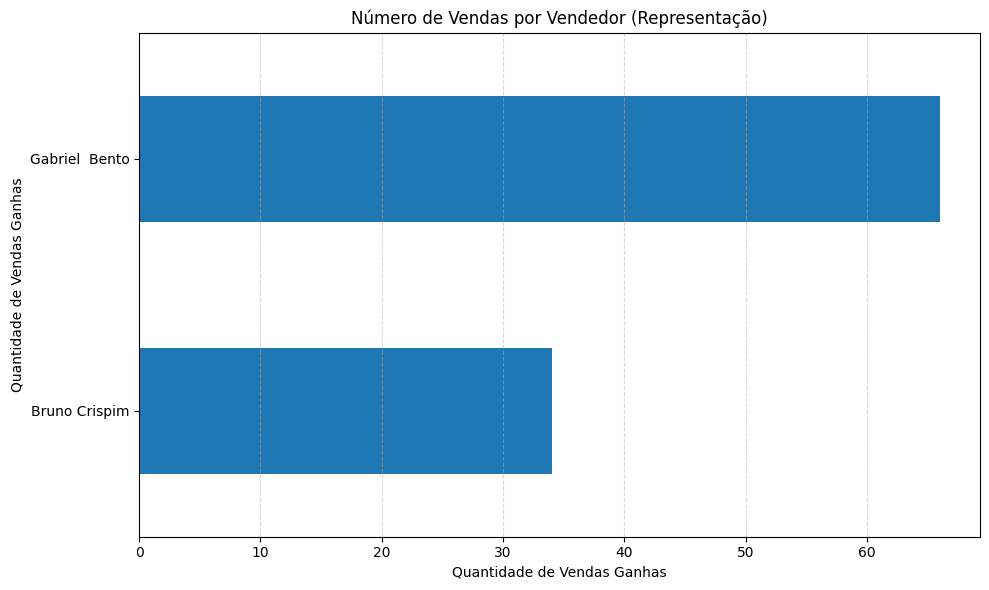

In [52]:
df_rep_ganhas = df_rep[df_rep["deal_stage.name"] == 'Venda Ganha']

vendas_por_vendedor = df_rep_ganhas["user.name"].value_counts().sort_values(ascending=True)


plt.figure(figsize=(10,6))
vendas_por_vendedor.plot(kind="barh")
plt.title('Número de Vendas por Vendedor (Representação)')
plt.xlabel("Quantidade de Vendas Ganhas")
plt.ylabel("Quantidade de Vendas Ganhas")
plt.tight_layout()
plt.grid(axis="x",linestyle = '--', alpha = 0.5)
plt.show()

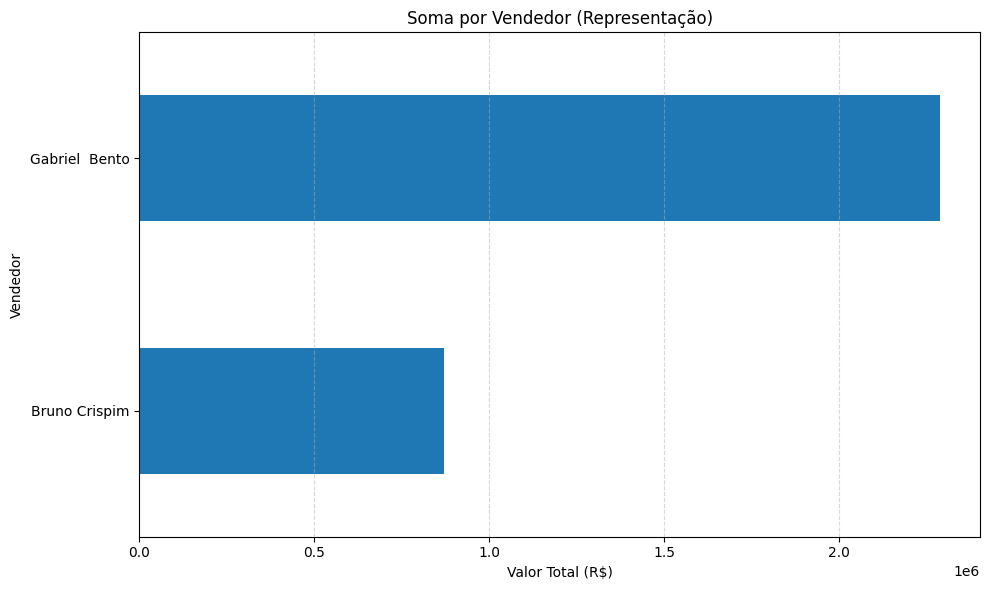

In [53]:
soma_por_vendedor = df_rep_ganhas.groupby('user.name')["amount_total"].sum()


plt.figure(figsize=(10,6))
soma_por_vendedor.plot(kind="barh")
plt.title("Soma por Vendedor (Representação)")
plt.xlabel("Valor Total (R$)")
plt.ylabel("Vendedor")
plt.grid(axis='x', linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

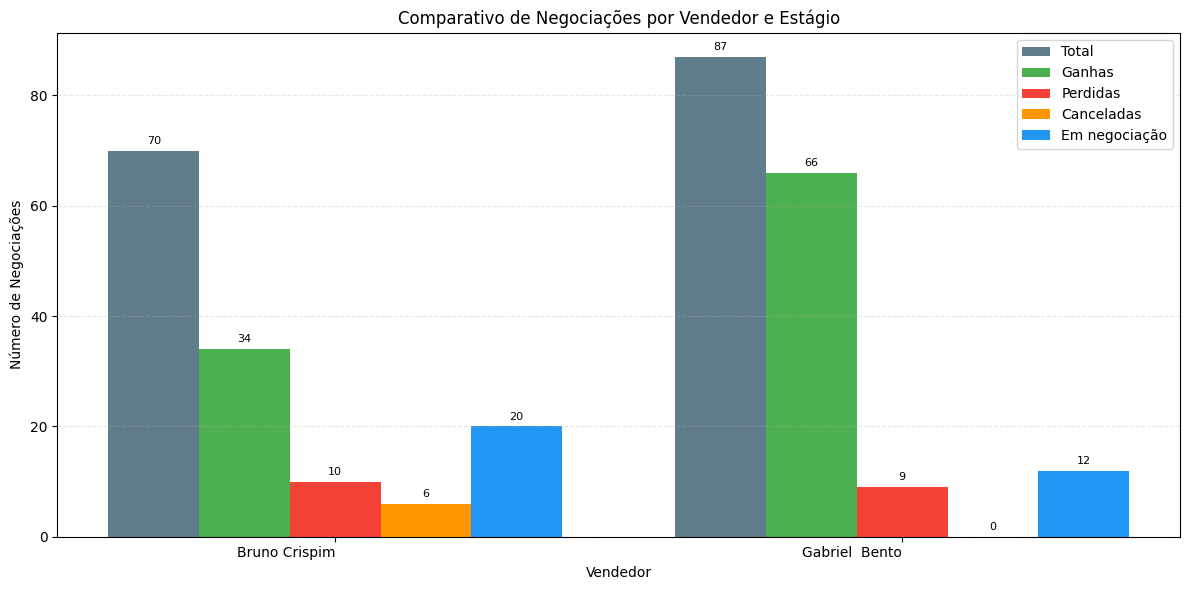

In [54]:
#Definindo os estágios de deal_stage.name que quero pegar
estágios = ["Venda Ganha", "Venda Perdida", "Venda Cancelada", "Negociação"] #lista com os estágios

#Criando DataFrame com os estágios que eu quero
df_rep_graf = df_rep[df_rep["deal_stage.name"].isin(estágios)].copy() #pega as linhas com os estágios de negociação já definidos

#Contando quantas negociações de cada estágio por vendedor
counts = df_rep_graf.groupby(["user.name", "deal_stage.name"]).size().unstack(fill_value=0) #faz a contagem dos estágios por vendedor e preenche os valores nulos por 0

#Adicionando coluna Total somando todos os estágios. 
counts['Total'] = counts.sum(axis=1)  #axis=1 faz a contagem por linha


#Dados para plotar o gráfico
vendedores = counts.index.tolist() #pega o index de counts ou seja o nome dos vendedores e transforma em uma lista python convencional
x = np.arange(len(vendedores)) #Cria um array com o número de vendedores (len(vendedores)) isso vai ser usado para cada vendedor ser posicionado no gráfico
n_barras = 5
total_width = 0.8
bar_width = total_width/n_barras
offsets = np.linspace(-total_width/2 + bar_width/2,total_width/2 - bar_width/2,n_barras)


series = [
    counts["Total"],
    counts.get("Venda Ganha", pd.Series(0, index=vendedores)),
    counts.get("Venda Perdida", pd.Series(0, index=vendedores)),
    counts.get("Venda Cancelada", pd.Series(0, index=vendedores)),
    counts.get("Negociação", pd.Series(0, index=vendedores)),
]

labels = ['Total', 'Ganhas', 'Perdidas', 'Canceladas', "Em negociação"]
colors = ["#607D8B", "#4CAF50", "#F44336", "#FF9800", "#2196F3"]

#Plotando o gráfico
plt.figure(figsize=(12,6))
bars = []

for off, serie, label, color in zip(offsets, series, labels, colors):
    b = plt.bar(x + off, serie, bar_width, label=label, color=color)
    bars.append(b)
    
plt.xticks(x,vendedores, ha='right')
plt.xlabel('Vendedor')
plt.ylabel("Número de Negociações")
plt.title("Comparativo de Negociações por Vendedor e Estágio")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

#Anotar valores acima de cada barra
altura_maxima = max(s.max() for s in series)
for bar_container in bars:
    for bar in bar_container:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + altura_maxima * 0.01,
            f"{int(h)}",
            ha="center", va="bottom", fontsize=8
        )

plt.tight_layout()
plt.show()


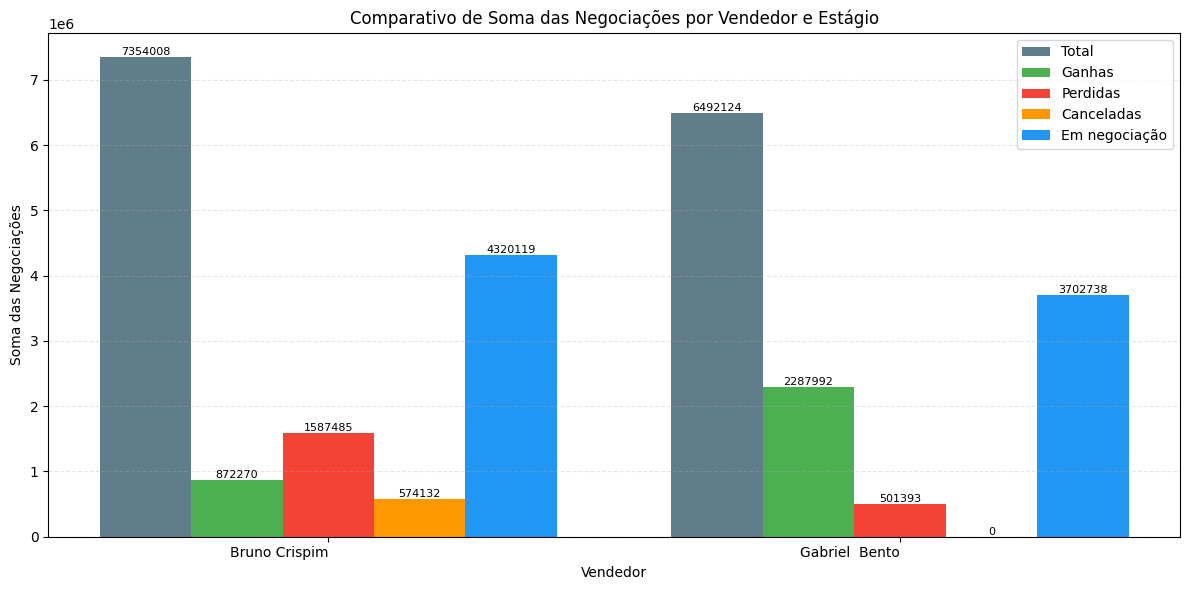

In [55]:
#Definindo os estágios de deal_stage.name que quero pegar
estágios = ["Venda Ganha", "Venda Perdida", "Venda Cancelada", "Negociação"] #lista com os estágios

#Criando DataFrame com os estágios que eu quero
df_rep_graf = df_rep[df_rep["deal_stage.name"].isin(estágios)].copy() #pega as linhas com os estágios de negociação já definidos


#Dados para plotar o gráfico
vendedores = counts.index.tolist() #pega o index de counts ou seja o nome dos vendedores e transforma em uma lista python convencional
x = np.arange(len(vendedores)) #Cria um array com o número de vendedores (len(vendedores)) isso vai ser usado para cada vendedor ser posicionado no gráfico
n_barras = 5
total_width = 0.8
bar_width = total_width/n_barras
offsets = np.linspace(-total_width/2 + bar_width/2,total_width/2 - bar_width/2,n_barras)


#Criando DataFrame com os estágios que eu quero
df_rep_graf = df_rep[df_rep["deal_stage.name"].isin(estágios)].copy() #pega as linhas com os estágios de negociação já definidos
soma = df_rep_graf.groupby(['user.name','deal_stage.name'])["amount_total"].sum().unstack(fill_value=0)

soma['Total'] = soma.sum(axis=1)
soma

series_soma = [
    soma["Total"],
    soma.get("Venda Ganha", pd.Series(0, index=vendedores)),
    soma.get("Venda Perdida", pd.Series(0, index=vendedores)),
    soma.get("Venda Cancelada", pd.Series(0, index=vendedores)),
    soma.get("Negociação", pd.Series(0, index=vendedores)),
]

#Plotando o gráfico
plt.figure(figsize=(12,6))
bars = []

for off, serie, label, color in zip(offsets, series_soma, labels, colors):
    b = plt.bar(x + off, serie, bar_width, label=label, color=color)
    bars.append(b)
    
plt.xticks(x,vendedores, ha='right')
plt.xlabel('Vendedor')
plt.ylabel("Soma das Negociações")
plt.title("Comparativo de Soma das Negociações por Vendedor e Estágio")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

#Anotar valores acima de cada barra
altura_maxima = max(s.max() for s in series)
for bar_container in bars:
    for bar in bar_container:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + altura_maxima * 0.01,
            f"{int(h)}",
            ha="center", va="bottom", fontsize=8
        )

plt.tight_layout()
plt.show()

In [57]:


caminho = r"C:\\Users\\Orçamento\\OneDrive - GRUPO RETEC\\02. Engenharia\\Dep. Orçamentos\\POWERBI\\AUTOMACAO RD\\data\\negociacoes_rep_2025.xlsx"
df_rep.to_excel(caminho)